In [1]:
Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 8)

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/iiitl/EDA-IPL/main/data/deliveries.csv')
print("Shape:",df.shape)
print("All columns:")
print(df.columns.tolist())
print(df.head())

Shape: (260920, 17)
All columns:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']
   match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
1     2  BB McCullum  P Kumar   SC Ganguly             0           0   
2     3  BB McCullum  P Kumar   SC Ga

In [9]:
#Filling NaN values
print("Before filling NaN:")
print(df.isnull().sum())
print("*="*25)
df['extras_type']=df['extras_type'].fillna('none')
df['player_dismissed']=df['player_dismissed'].fillna('none')
df['dismissal_kind']=df['dismissal_kind'].fillna('none')
df['fielder']=df['fielder'].fillna('none')
print("After filling NaN:")
print(df.isnull().sum())
print("*="*25)
print("Unique extra types:")
print(df['extras_type'].unique())

Before filling NaN:
match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64
*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=
After filling NaN:
match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64
*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=
Unique extra types:
['legbyes' 'none' 'wides' 'byes' 'noballs' 'penalty']


In [18]:
#Filter Innings and Group Data
df_filtered=df[df['inning'].isin([1,2])]
print("Number of rows before filtering:",len(df_filtered))
print("Number of rows after filtering:",len(df_filtered))

extra_types=['wides','noballs','legbyes','byes']
df_extras=df_filtered[df_filtered['extras_type'].isin(extra_types)]
print("total extra deliveries found:",len(df_extras))

grouped=df_extras.groupby(['bowling_team','inning','extras_type'])['extra_runs'].sum().reset_index()
grouped.columns = ['bowling_team', 'inning', 'extras_type', 'total_runs']
print("Grouped data sample:")
print(grouped.head(12))

pivot=grouped.pivot_table(index=['bowling_team','inning'],columns='extras_type',values='total_runs',fill_value=0).reset_index()
for col in extra_types:
    if col not in pivot.columns:
        pivot[col] = 0


pivot['total_extras'] = pivot[extra_types].sum(axis=1)
print("Pivoted table (each extra type is now a column):")
print(pivot.head(10))


Number of rows before filtering: 260759
Number of rows after filtering: 260759
total extra deliveries found: 14104
Grouped data sample:
           bowling_team  inning extras_type  total_runs
0   Chennai Super Kings       1        byes          49
1   Chennai Super Kings       1     legbyes         258
2   Chennai Super Kings       1     noballs          39
3   Chennai Super Kings       1       wides         488
4   Chennai Super Kings       2        byes          59
5   Chennai Super Kings       2     legbyes         301
6   Chennai Super Kings       2     noballs          63
7   Chennai Super Kings       2       wides         585
8       Deccan Chargers       1        byes          34
9       Deccan Chargers       1     legbyes          92
10      Deccan Chargers       1     noballs          28
11      Deccan Chargers       1       wides         140
Pivoted table (each extra type is now a column):
extras_type         bowling_team  inning  byes  legbyes  noballs  wides  \
0           

In [26]:

matches_count = df_filtered.groupby(
    ['bowling_team', 'inning']
)['match_id'].nunique().reset_index()
matches_count.columns = ['bowling_team', 'inning', 'matches_played']


pivot = pivot.merge(matches_count, on=['bowling_team', 'inning'], how='left')
pivot['matches_played'] = pivot['matches_played'].fillna(1)

pivot['avg_extras'] = (
    pivot['total_extras'] / pivot['matches_played']
).round(2)

print("Columns now:")
print(pivot.columns.tolist())
print("\nFinal table sample:")
print(pivot.sort_values('avg_extras').head(10))

Columns now:
['bowling_team', 'inning', 'byes', 'legbyes', 'noballs', 'wides', 'total_extras', 'matches_played', 'avg_extras']

Final table sample:
              bowling_team  inning  byes  legbyes  noballs  wides  \
8            Gujarat Lions       1   5.0     32.0      5.0   48.0   
37     Sunrisers Hyderabad       2  43.0    178.0     23.0  344.0   
10          Gujarat Titans       1   3.0     42.0      8.0  103.0   
11          Gujarat Titans       2  14.0     43.0      4.0   78.0   
23           Pune Warriors       2  14.0     34.0      8.0   78.0   
28  Rising Pune Supergiant       1   2.0     23.0      1.0   28.0   
9            Gujarat Lions       2   5.0     32.0      2.0   59.0   
29  Rising Pune Supergiant       2   1.0     15.0      0.0   41.0   
25            Punjab Kings       2  10.0     71.0     14.0  130.0   
5           Delhi Capitals       2  15.0     89.0     21.0  178.0   

    total_extras  matches_played  avg_extras  
8           90.0              16        5.62 

Teams included in chart: 19
['Mumbai Indians', 'Kolkata Knight Riders', 'Royal Challengers Bangalore', 'Rajasthan Royals', 'Chennai Super Kings', 'Kings XI Punjab', 'Delhi Daredevils', 'Sunrisers Hyderabad', 'Delhi Capitals', 'Deccan Chargers', 'Punjab Kings', 'Pune Warriors', 'Lucknow Super Giants', 'Gujarat Titans', 'Gujarat Lions', 'Royal Challengers Bengaluru', 'Kochi Tuskers Kerala', 'Rising Pune Supergiant', 'Rising Pune Supergiants']


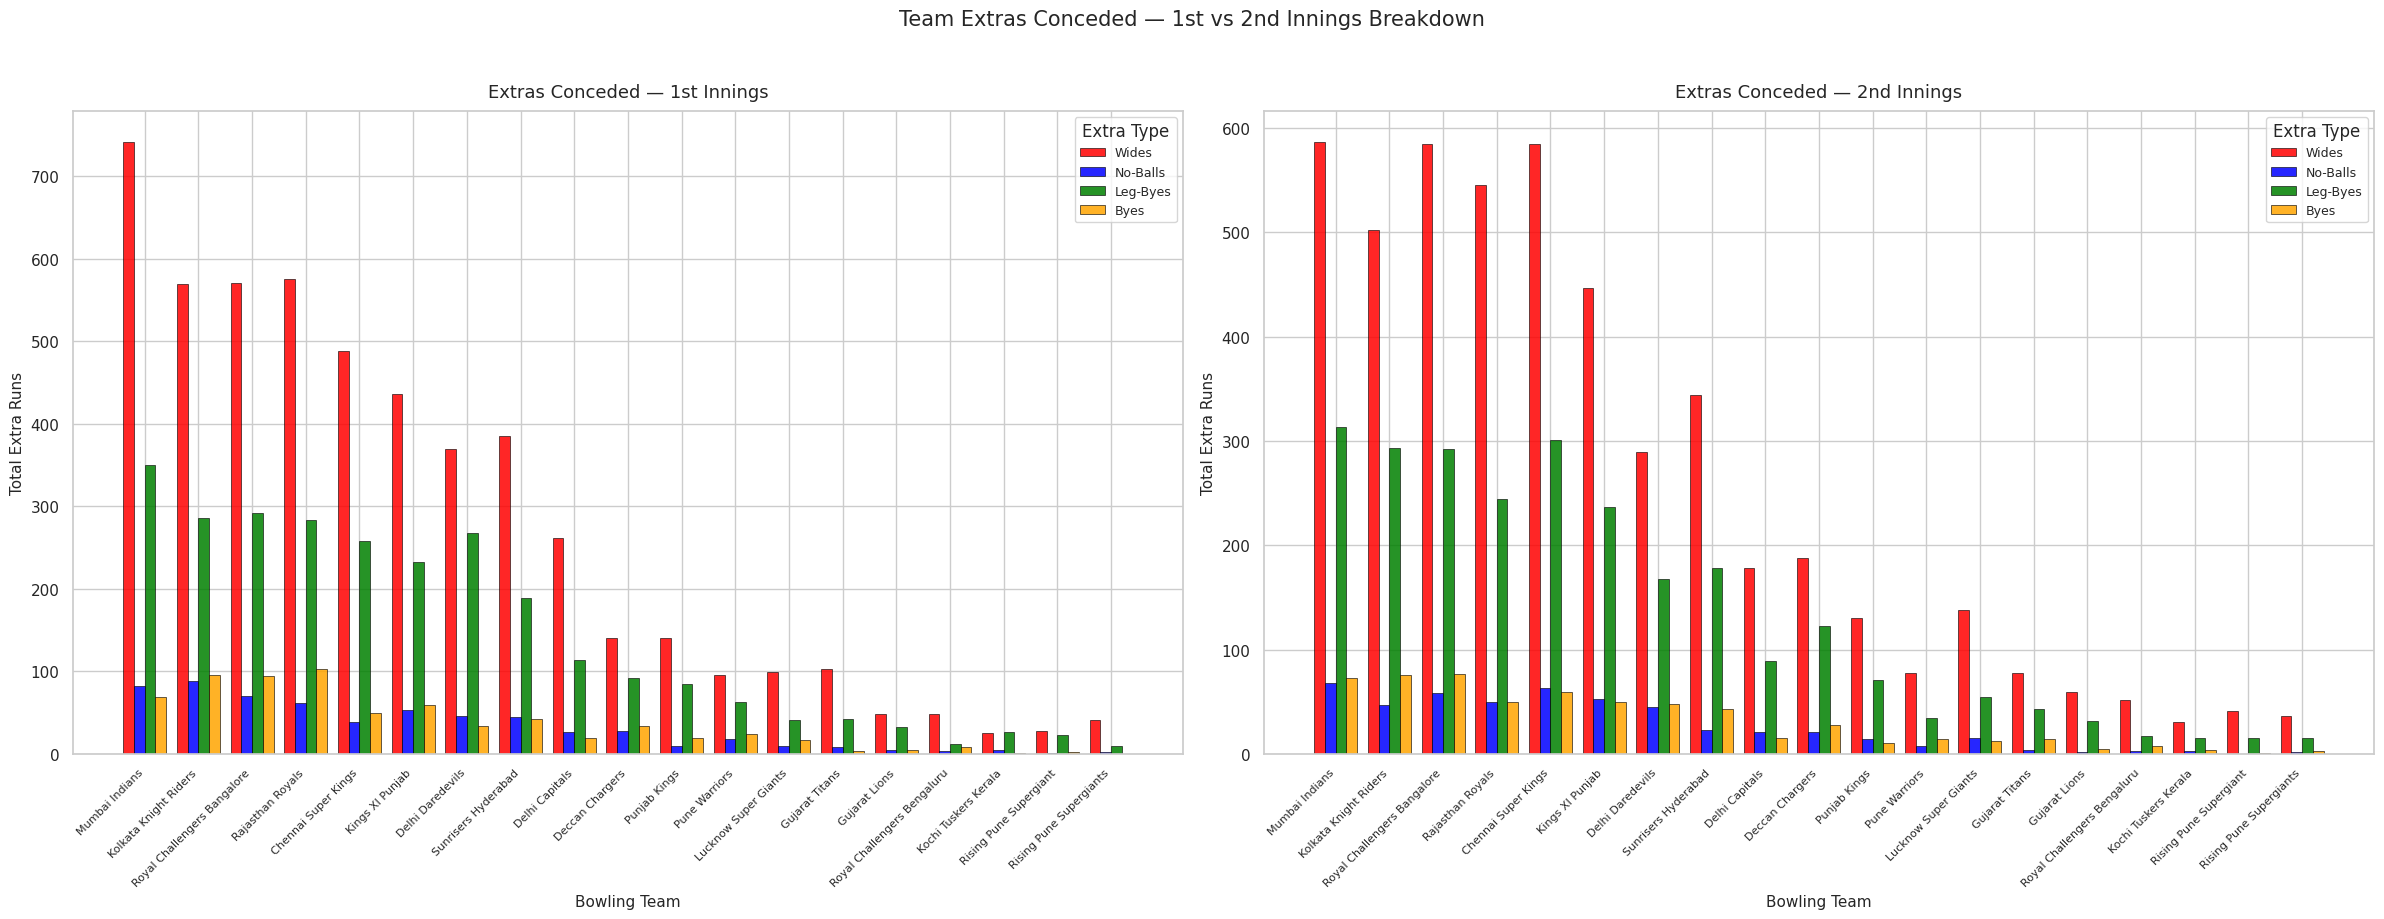

In [23]:

inn1 = pivot[pivot['inning'] == 1].set_index('bowling_team')
inn2 = pivot[pivot['inning'] == 2].set_index('bowling_team')
teams = inn1['total_extras'].sort_values(ascending=False).index.tolist()
teams = [t for t in teams if t in inn2.index]
print(f"Teams included in chart: {len(teams)}")
print(teams)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 9))
x = np.arange(len(teams))
width = 0.2
colors = ['red', 'blue', 'green', 'orange']
labels = ['Wides', 'No-Balls', 'Leg-Byes', 'Byes']


# 1ST INNINGS CHART
for i, col in enumerate(extra_types):
    values = [inn1.loc[t, col] if t in inn1.index else 0 for t in teams]
    ax1.bar(
        x + i * width,
        values,
        width,
        label=labels[i],
        color=colors[i],
        alpha=0.85,
        edgecolor='black',
        linewidth=0.5
    )

ax1.set_title('Extras Conceded — 1st Innings', fontsize=13, pad=10)
ax1.set_xlabel('Bowling Team', fontsize=11)
ax1.set_ylabel('Total Extra Runs', fontsize=11)
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(teams, rotation=45, ha='right', fontsize=8)
ax1.legend(title='Extra Type', fontsize=9)

# 2ND INNINGS CHART
for i, col in enumerate(extra_types):
    values = [inn2.loc[t, col] if t in inn2.index else 0 for t in teams]
    ax2.bar(x + i * width, values, width,
            label=labels[i], color=colors[i],
            alpha=0.85, edgecolor='black', linewidth=0.5)

ax2.set_title('Extras Conceded — 2nd Innings', fontsize=13, pad=10)
ax2.set_xlabel('Bowling Team', fontsize=11)
ax2.set_ylabel('Total Extra Runs', fontsize=11)
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(teams, rotation=45, ha='right', fontsize=8)
ax2.legend(title='Extra Type', fontsize=9)

plt.suptitle(
    'Team Extras Conceded — 1st vs 2nd Innings Breakdown',
    fontsize=15, y=1.02
)
plt.tight_layout()
plt.savefig('team_extras_conceded.png', bbox_inches='tight')
plt.show()

In [27]:
summary = pivot.groupby('bowling_team')['avg_extras'].mean().round(2)
summary = summary.sort_values()
print("*=" * 25)
print("MOST DISCIPLINED TEAMS (fewest avg extras per match)")
print("+=" * 25)
print(summary.head(5))
print("LEAST DISCIPLINED TEAMS (fewest avg extras per match)")
print("+=" * 25)
print(summary.tail(5))

wide_heavy = pivot.groupby('bowling_team')['wides'].sum().sort_values(ascending=False)
print("nTop 5 wide-heavy teams:")
print(wide_heavy.head(5))

legbye_heavy = pivot.groupby('bowling_team')['legbyes'].sum().sort_values(ascending=False)
print("Top 5 legbye-heavy teams:")
print(legbye_heavy.head(5))

inning_comparison = pivot.groupby('inning')['avg_extras'].mean().round(2)
print("\nAverage extras per match by inning:")
print(inning_comparison)


*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=
MOST DISCIPLINED TEAMS (fewest avg extras per match)
+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=
bowling_team
Gujarat Lions             6.31
Gujarat Titans            6.56
Sunrisers Hyderabad       6.88
Rising Pune Supergiant    6.94
Pune Warriors             7.22
Name: avg_extras, dtype: float64
LEAST DISCIPLINED TEAMS (fewest avg extras per match)
+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=
bowling_team
Punjab Kings                    8.73
Deccan Chargers                 8.78
Mumbai Indians                  8.78
Lucknow Super Giants            8.95
Royal Challengers Bengaluru    10.36
Name: avg_extras, dtype: float64
nTop 5 wide-heavy teams:
bowling_team
Mumbai Indians                 1329.0
Royal Challengers Bangalore    1155.0
Rajasthan Royals               1120.0
Chennai Super Kings            1073.0
Kolkata Knight Riders          1071.0
Name: wides, dtype: float64
Top 5 legbye-heavy teams:
bowling_team
Mumbai Indian